---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 16. Кореляційний аналіз та модуляція сигналів</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Кореляційний аналіз та модуляція сигналів</li>
  <li>Взаємна спектральна густина сигналів. Енергетичний спектр</li>
  <li>Кореляційний аналіз сигналів. Порівняння сигналів, зсунутих у часі</li>
  <li>Автокореляційна функція сигналу та її властивості</li>
  <li>Взаємокореляційна функція двох сигналів та її властивості</li>
  <li>Модульовані сигнали: основні поняття та області застосування</li>
  <li>Амплітудна модуляція: спектральні діаграми та енергетичні характеристики</li>
  <li>Балансна та односмугова амплітудні модуляції</li>
  <li>Фазова та частотна модуляції: спектральні діаграми та енергетичні характеристики</li>
  <li>Сигнали з обмеженим спектром</li>
  <li>Теорема Котельникова. Побудова ортонормованого базису та ряд Котельникова</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 16 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Кореляційний аналіз та модуляція сигналів](#correlation-modulation)
    * [Взаємна спектральна густина сигналів. Енергетичний спектр](#cross-spectral-density)
    * [Кореляційний аналіз сигналів. Порівняння сигналів, зсунутих у часі](#correlation-analysis)
    * [Автокореляційна функція сигналу та її властивості](#autocorrelation)
    * [🔬 Інтерактивно: як будується автокореляційна функція](#acf-interactive)
    * [Взаємокореляційна функція двох сигналів та її властивості](#cross-correlation)
    * [Модульовані сигнали: основні поняття та області застосування](#modulation-basics)
    * [Амплітудна модуляція: спектральні діаграми та енергетичні характеристики](#am-modulation)
    * [🔬 Інтерактивно: коефіцієнт модуляції та перемодуляція](#am-interactive)
    * [Балансна та односмугова амплітудні модуляції](#dsb-ssb-modulation)
    * [Фазова та частотна модуляції: спектральні діаграми та енергетичні характеристики](#fm-pm-modulation)
    * [Сигнали з обмеженим спектром](#band-limited-signals)
    * [Теорема Котельникова. Побудова ортонормованого базису та ряд Котельникова](#kotelnikov-theorem)
    * [🔬 Інтерактивно: частота дискретизації та накладання спектрів (aliasing)](#aliasing-interactive)
* [📌 Підсумок курсу: Основи радіоелектроніки. Частина 2](#summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Кореляційний аналіз та модуляція сигналів <a class="anchor" id="correlation-modulation"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Обчислювати енергетичний спектр і взаємну спектральну густину сигналів
> - Пояснювати фізичний зміст автокореляційної та взаємокореляційної функцій та їх властивості
> - Записувати спектр і енергетичні характеристики АМ, балансної, однополосної, ЧМ та ФМ модуляції
> - Формулювати теорему Котельникова і будувати ряд Котельникова для сигналу з обмеженим спектром

</div>

### Взаємна спектральна густина сигналів. Енергетичний спектр <a class="anchor" id="cross-spectral-density"></a>

За формулою Релея (розділ вище) величина $W(\omega)=|F(j\omega)|^2$ — **енергетичний спектр** (спектральна густина енергії) сигналу $f(t)$: вона показує розподіл енергії сигналу за частотою, причому $W(\omega)\ge0$ і $W(-\omega)=W(\omega)$ (парна функція для дійсного сигналу).

Для **двох** сигналів $x(t)$ і $y(t)$ зі спектрами $X(j\omega)$, $Y(j\omega)$ вводять **взаємну спектральну густину**:

$$W_{xy}(\omega) = X(j\omega)\,Y^{*}(j\omega)$$

На відміну від енергетичного спектра одного сигналу, $W_{xy}(\omega)$ — комплексна і, взагалі кажучи, не парна функція; вона показує, наскільки узгоджено два сигнали змінюються на кожній частоті. Нижче показано, що взаємна спектральна густина й кореляційна функція двох сигналів пов'язані перетворенням Фур'є (теорема Вінера–Хінчина) — так само, як енергетичний спектр пов'язаний з автокореляційною функцією.


### Кореляційний аналіз сигналів. Порівняння сигналів, зсунутих у часі <a class="anchor" id="correlation-analysis"></a>

**Кореляційний аналіз** дає кількісну міру **схожості** двох сигналів — або одного сигналу з власною зсунутою в часі копією — залежно від величини зсуву $\tau$. Для сигналів зі скінченною енергією вводять **кореляційний інтеграл**:

$$R_{xy}(\tau) = \int_{-\infty}^{\infty} x(t)\,y(t+\tau)\,dt$$

Чим більше значення $|R_{xy}(\tau)|$ при деякому $\tau$, тим краще $x(t)$ узгоджується з $y(t)$, зсунутим саме на цей інтервал часу. Максимум кореляційної функції за $\tau$ вказує **найкращий момент вирівнювання (затримку)** між сигналами — на цьому й ґрунтується виявлення сигналів на тлі завад, вимірювання відстані (радіолокація, гідролокація) та синхронізація в цифровому зв'язку.


### Автокореляційна функція сигналу та її властивості <a class="anchor" id="autocorrelation"></a>

**Автокореляційна функція (АКФ)** — окремий випадок кореляційного інтеграла, коли другий сигнал — це той самий $x(t)$:

$$R_x(\tau) = \int_{-\infty}^{\infty} x(t)\,x(t+\tau)\,dt$$

**Властивості АКФ:**

| Властивість | Формулювання |
|-------------|--------------|
| Максимум при $\tau=0$ | $R_x(0) = \displaystyle\int|x(t)|^2dt = E$ (енергія сигналу), і $R_x(\tau)\le R_x(0)\;\forall\tau$ |
| Парність | $R_x(-\tau)=R_x(\tau)$ для дійсного $x(t)$ |
| Згасання | Для сигналів без періодичної складової $R_x(\tau)\to0$ при $\tau\to\infty$ (декореляція) |
| Теорема Вінера–Хінчина | $R_x(\tau)$ і енергетичний спектр $W(\omega)=|X(j\omega)|^2$ пов'язані перетворенням Фур'є: $W(\omega)=\displaystyle\int_{-\infty}^{\infty}R_x(\tau)e^{-j\omega\tau}d\tau$ |

Отже, АКФ і енергетичний спектр несуть еквівалентну інформацію про сигнал, лише в різних (часовій і частотній) областях.


---
### 🔬 Інтерактивно: як будується автокореляційна функція <a class="anchor" id="acf-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Зсувайте копію сигналу на $\tau$ відліків: значення АКФ — це площа під добутком сигналу і його зсунутої копії. Для **коду Баркера** довжини 13 АКФ має гострий пік $B(0) = 13$ і бічні пелюстки не більше 1 — тому такі сигнали використовують у радіолокації та зв'язку для точного вимірювання затримки.

</div>

In [2]:
# Інтерактивно: побудова АКФ коду Баркера (N = 13) зсувом копії сигналу
barker13 = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])

def acf_demo(shift=3, code_type='Баркер-13'):
    x = barker13 if code_type == 'Баркер-13' else np.ones(13)
    N = len(x)
    lags = np.arange(-(N - 1), N)
    acf = np.correlate(x, x, mode='full')
    n = np.arange(-N, 2*N)
    xs = np.zeros(n.size); xs[(n >= 0) & (n < N)] = x
    ys = np.zeros(n.size); ys[(n >= shift) & (n < N + shift)] = x

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.step(n, xs, where='post', label='$x(n)$')
    ax1.step(n, ys + 0.05, where='post', label=f'$x(n-\\tau)$, τ = {shift}')
    ax1.fill_between(n, xs*ys, step='post', alpha=0.3, color='g', label='добуток')
    ax1.set_ylim(-1.5, 1.8); ax1.legend(loc='upper right'); ax1.set_xlabel('n')
    ax1.set_title('Сигнал і його зсунута копія')
    ax2.stem(lags, acf, basefmt=' ')
    k = shift + N - 1
    ax2.plot(shift, acf[k], 'ro', ms=10)
    ax2.set_xlabel('τ, відліки'); ax2.set_title(f'АКФ: B({shift}) = {acf[k]:.0f}')
    plt.tight_layout(); plt.show()

interact(acf_demo,
         shift=widgets.IntSlider(value=3, min=-12, max=12, description='τ'),
         code_type=widgets.ToggleButtons(options=['Баркер-13', 'Прямокутний імпульс'], description='Сигнал'));

interactive(children=(IntSlider(value=3, description='τ', max=12, min=-12), ToggleButtons(description='Сигнал'…

### Взаємокореляційна функція двох сигналів та її властивості <a class="anchor" id="cross-correlation"></a>

**Взаємокореляційна функція (ВКФ)** — загальний випадок $R_{xy}(\tau)$ для двох **різних** сигналів. Властивості:

- **Несиметрична відносно перестановки:** $R_{xy}(\tau) = R_{yx}(-\tau)$ (на відміну від АКФ, взагалі не парна функція).
- **Нерівність Коші–Буняковського:** $|R_{xy}(\tau)| \le \sqrt{R_x(0)\,R_y(0)}$ — ВКФ обмежена «геометричним середнім» енергій обох сигналів.
- Положення максимуму $\tau_{max}=\arg\max_\tau|R_{xy}(\tau)|$ дає оцінку **затримки** одного сигналу відносно іншого — принцип роботи **узгодженого фільтра (matched filter)**: кореляція прийнятого сигналу з еталонним (опорним) сигналом виявляє його на тлі шуму й визначає затримку (наприклад, час поширення сигналу радара до цілі й назад).


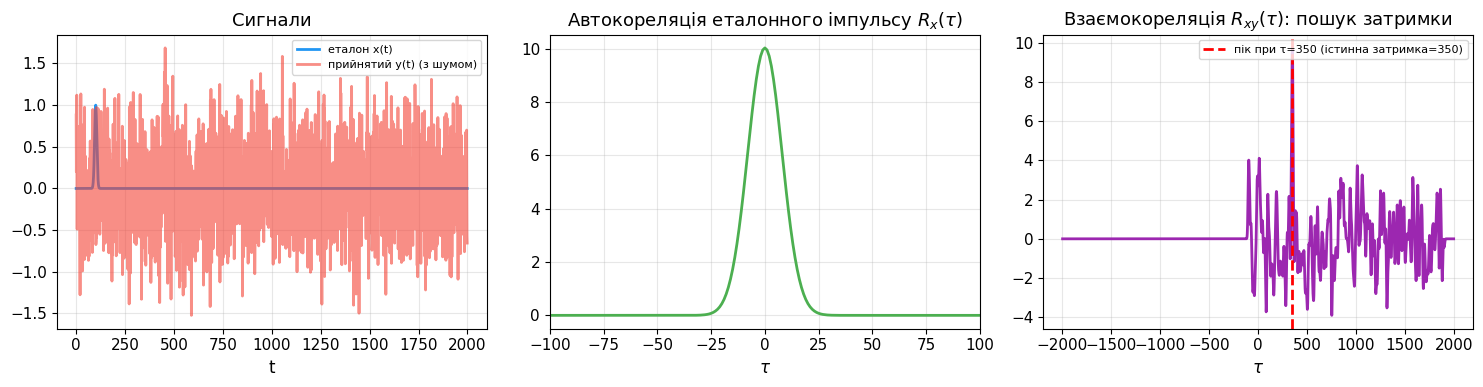

Істинна затримка: 350. Затримка, знайдена за максимумом ВКФ: 350.


In [3]:
# Демонстрація АКФ і ВКФ: виявлення затримки сигналу на тлі шуму методом кореляції
np.random.seed(0)
N_c = 2000
t_c = np.arange(N_c)
pulse = np.exp(-((t_c-100)/8.0)**2)              # короткий еталонний імпульс (опорний сигнал)

delay_true = 350
received = np.roll(pulse, delay_true) + 0.5*np.random.randn(N_c)   # прийнятий сигнал: затриманий імпульс + шум

acf = np.correlate(pulse, pulse, mode='full')
ccf = np.correlate(received, pulse, mode='full')
lags = np.arange(-N_c+1, N_c)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_c, pulse, '#2196F3', label='еталон x(t)')
axes[0].plot(t_c, received, '#F44336', alpha=0.6, label='прийнятий y(t) (з шумом)')
axes[0].set_xlabel('t'); axes[0].set_title('Сигнали'); axes[0].legend(fontsize=8)

axes[1].plot(lags, acf, '#4CAF50')
axes[1].set_xlim(-100, 100)
axes[1].set_xlabel(r'$\tau$'); axes[1].set_title('Автокореляція еталонного імпульсу $R_x(\\tau)$')

axes[2].plot(lags, ccf, '#9C27B0')
peak_lag = lags[np.argmax(ccf)]
axes[2].axvline(peak_lag, color='red', ls='--', label=f'пік при τ={peak_lag} (істинна затримка={delay_true})')
axes[2].set_xlabel(r'$\tau$'); axes[2].set_title('Взаємокореляція $R_{xy}(\\tau)$: пошук затримки')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Істинна затримка: {delay_true}. Затримка, знайдена за максимумом ВКФ: {peak_lag}.')


### Модульовані сигнали: основні поняття та області застосування <a class="anchor" id="modulation-basics"></a>

**Модуляція** — процес зміни одного чи кількох параметрів високочастотного гармонічного коливання (**несучої**) $u_н(t)=U_m\cos(\omega_0t+\varphi_0)$ за законом, що відповідає низькочастотному **інформаційному (модулюючому)** сигналу $s(t)$. Залежно від того, який параметр змінюється, розрізняють:

| Вид модуляції | Змінюваний параметр |
|----------------|----------------------|
| **Амплітудна (АМ)** | Амплітуда $U_m$ |
| **Фазова (ФМ)** | Початкова фаза $\varphi_0$ |
| **Частотна (ЧМ)** | Частота $\omega_0$ |

ФМ і ЧМ разом називають **кутовою модуляцією**, оскільки в обох випадках змінюється повна фаза коливання $\theta(t)=\omega_0t+\varphi(t)$.

**Навіщо потрібна модуляція:**
- **Узгодження з антеною** — ефективне випромінювання вимагає розміру антени порядку довжини хвилі; перенесення низькочастотного сигналу на високу несучу частоту робить антену практичного розміру можливою.
- **Розділення каналів (частотне ущільнення)** — різні передавачі використовують різні несучі частоти, тому багато незалежних сигналів можуть передаватися одночасно, не заважаючи одне одному.
- **Завадостійкість** — кутова модуляція (ЧМ/ФМ) значно менш чутлива до амплітудних завад, ніж АМ.

**Застосування:** радіомовлення (АМ на ДХ/СХ/КХ, ЧМ на УКХ), телебачення, мобільний і супутниковий зв'язок, радіолокація.


### Амплітудна модуляція: спектральні діаграми та енергетичні характеристики <a class="anchor" id="am-modulation"></a>

Для тональної (однотонової) АМ модулюючий сигнал — гармонічний, $s(t)=U_\Omega\cos\Omega t$:

$$s_{АМ}(t) = U_m\bigl(1+m\cos\Omega t\bigr)\cos\omega_0 t, \qquad m=\frac{U_\Omega}{U_m}\in[0,1]$$

де $m$ — **коефіцієнт (глибина) модуляції** ($m>1$ призводить до перемодуляції й спотворення обвідної). Розкриваючи добуток, отримуємо суму трьох гармонік:

$$s_{АМ}(t) = U_m\cos\omega_0t + \frac{mU_m}{2}\cos(\omega_0-\Omega)t + \frac{mU_m}{2}\cos(\omega_0+\Omega)t$$

тобто **несуча** ($\omega_0$) плюс **нижня** (НБС, $\omega_0-\Omega$) і **верхня** (ВБС, $\omega_0+\Omega$) **бічні смуги**. Для довільного (не гармонічного) модулюючого сигналу з максимальною частотою спектра $F_{max}$ ширина спектра АМ-сигналу:

$$\Delta f_{АМ} = 2F_{max}$$

**Потужності:** $P_{несуча}=\dfrac{U_m^2}{2R}$, кожна бічна смуга $P_{бс}=\dfrac{m^2U_m^2}{8R}$, повна потужність:

$$P_{АМ} = P_{несуча}\left(1+\frac{m^2}{2}\right)$$

При максимальній глибині модуляції $m=1$ обидві бічні смуги несуть разом лише $1/3$ повної потужності — основний недолік класичної АМ: значна частина потужності «марно» витрачається на несучу, яка сама по собі не переносить інформації.


Побудуємо часову та спектральну діаграми АМ-сигналу:

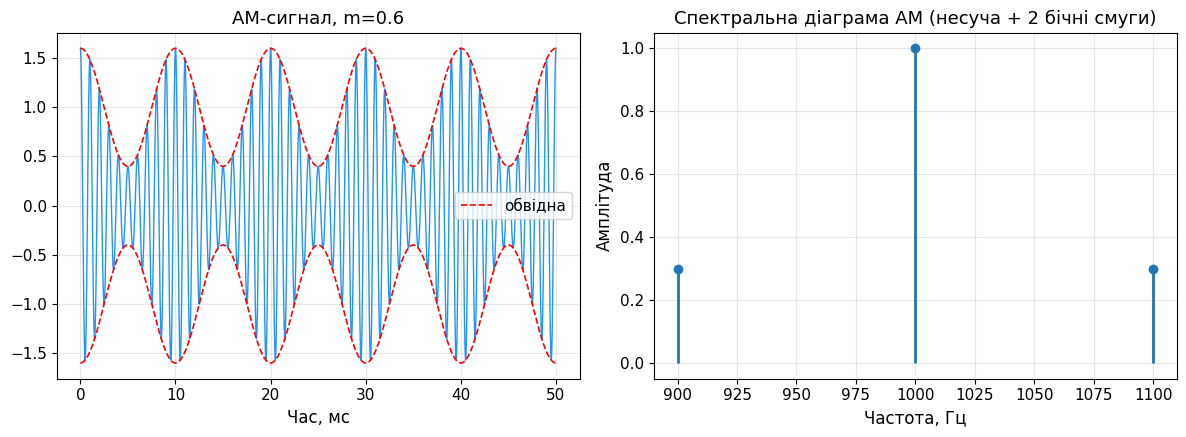

P_несуча = 0.500 (відн. од.), P_повна = 0.590, частка бічних смуг = 15.3%


In [4]:
# Амплітудна модуляція: часова діаграма і спектральна діаграма (3 лінії)
Um_am, f0_am, F_am, m_am = 1.0, 1000.0, 100.0, 0.6
w0_am, W_am = 2*np.pi*f0_am, 2*np.pi*F_am
t_am = np.linspace(0, 5/F_am, 5000)
s_am = Um_am*(1+m_am*np.cos(W_am*t_am))*np.cos(w0_am*t_am)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(t_am*1e3, s_am, '#2196F3', lw=1)
ax1.plot(t_am*1e3, Um_am*(1+m_am*np.cos(W_am*t_am)), 'r--', lw=1.2, label='обвідна')
ax1.plot(t_am*1e3, -Um_am*(1+m_am*np.cos(W_am*t_am)), 'r--', lw=1.2)
ax1.set_xlabel('Час, мс'); ax1.set_title(f'АМ-сигнал, m={m_am}'); ax1.legend()

freqs_am = [f0_am-F_am, f0_am, f0_am+F_am]
amps_am = [m_am*Um_am/2, Um_am, m_am*Um_am/2]
ax2.stem(freqs_am, amps_am, basefmt=' ')
ax2.set_xlabel('Частота, Гц'); ax2.set_ylabel('Амплітуда')
ax2.set_title('Спектральна діаграма АМ (несуча + 2 бічні смуги)')
plt.tight_layout(); plt.show()

P_carrier = Um_am**2/2
P_am_total = P_carrier*(1+m_am**2/2)
print(f'P_несуча = {P_carrier:.3f} (відн. од.), P_повна = {P_am_total:.3f}, частка бічних смуг = {(P_am_total-P_carrier)/P_am_total*100:.1f}%')


---
### 🔬 Інтерактивно: коефіцієнт модуляції та перемодуляція <a class="anchor" id="am-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Змінюйте коефіцієнт модуляції $m$. При $m \le 1$ обвідна повторює модулюючий сигнал; при $m > 1$ настає **перемодуляція** — обвідна спотворюється, і простий амплітудний детектор уже не відновить повідомлення. Зверніть увагу, яка частка потужності припадає на бічні смуги: навіть при $m = 1$ це лише 1/3.

</div>

In [5]:
# Інтерактивно: АМ-сигнал при різних коефіцієнтах модуляції
def am_demo(m=0.5, F=1.0):
    U0, f0 = 1.0, 20.0                       # амплітуда і частота несучої (умовні одиниці)
    t = np.linspace(0, 2, 8000)
    env = U0*(1 + m*np.cos(2*np.pi*F*t))
    s = env*np.cos(2*np.pi*f0*t)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [2, 1]})
    ax1.plot(t, s, lw=1)
    ax1.plot(t, env, 'r--', lw=1.5, label='обвідна $U_0(1+m\\cos\\Omega t)$')
    ax1.plot(t, np.abs(env), 'g:', lw=1.5, label='вихід амплітудного детектора')
    ax1.set_xlabel('t'); ax1.legend(loc='upper right')
    ax1.set_title('Перемодуляція!' if m > 1 else f'АМ-сигнал, m = {m:.2f}', color='r' if m > 1 else 'k')
    ax2.stem([f0 - F, f0, f0 + F], [m*U0/2, U0, m*U0/2], basefmt=' ')
    ax2.set_xlim(f0 - 4, f0 + 4); ax2.set_xlabel('f'); ax2.set_title('Спектр')
    eta = m**2/(2 + m**2)
    ax2.text(0.02, 0.95, f'частка потужності\nв бічних смугах: {100*eta:.1f} %',
             transform=ax2.transAxes, va='top')
    plt.tight_layout(); plt.show()

interact(am_demo,
         m=widgets.FloatSlider(value=0.5, min=0, max=1.5, step=0.05, description='m'),
         F=widgets.FloatSlider(value=1.0, min=0.5, max=3, step=0.25, description='F'));

interactive(children=(FloatSlider(value=0.5, description='m', max=1.5, step=0.05), FloatSlider(value=1.0, desc…

### Балансна та односмугова амплітудні модуляції <a class="anchor" id="dsb-ssb-modulation"></a>

**Балансна модуляція (DSB-SC — Double SideBand Suppressed Carrier)** отримується перемножувачем (балансним модулятором), а не суматором: несуча в спектрі відсутня (**придушена**):

$$s_{ДБП}(t) = mU_m\cos\Omega t \cdot \cos\omega_0t = \frac{mU_m}{2}\cos(\omega_0-\Omega)t + \frac{mU_m}{2}\cos(\omega_0+\Omega)t$$

Оскільки вся потужність тепер зосереджена лише в двох бічних смугах (немає «марної» несучої), ДБП ефективніше використовує потужність передавача, ніж класична АМ, але вимагає **когерентного (синхронного) детектування** на прийомі — простий діодний детектор обвідної тут не працює, оскільки немає несучої, відносно якої обвідна визначена.

**Односмугова модуляція (SSB/ОБП — Single SideBand)** передає лише **одну** бічну смугу (фільтрацією зайвої смуги або фазовим методом Хартлі), тому ширина спектра вдвічі менша:

$$\Delta f_{SSB} = F_{max}$$

**Порівняння видів амплітудної модуляції:**

| Вид | Ширина спектра | Потужність у несучій | Складність приймача |
|-----|-----------------|------------------------|------------------------|
| Класична АМ | $2F_{max}$ | Значна (до 2/3 повної при m=1) | Проста (детектор обвідної) |
| Балансна (ДБП) | $2F_{max}$ | Відсутня | Потрібне когерентне детектування |
| Односмугова (ОБП) | $F_{max}$ | Відсутня | Найскладніша (потрібен опорний генератор і фазування/фільтрація) |


### Фазова та частотна модуляції: спектральні діаграми та енергетичні характеристики <a class="anchor" id="fm-pm-modulation"></a>

Загальна форма кутово-модульованого коливання: $s(t)=U_m\cos(\omega_0t+\varphi(t))$. При **фазовій модуляції (ФМ)** фаза пропорційна модулюючому сигналу $\varphi(t)=k_ф s(t)$; при **частотній модуляції (ЧМ)** пропорційна модулюючому сигналу — миттєва частота $\omega(t)=\omega_0+k_ч s(t)$, тобто $\varphi(t)=k_ч\int s(t)\,dt$ — ФМ і ЧМ математично зв'язані інтегруванням/диференціюванням модулюючого сигналу.

Для тональної ЧМ ($s(t)=U_\Omega\cos\Omega t$):

$$s_{ЧМ}(t) = U_m\cos(\omega_0t + m_ч\sin\Omega t), \qquad m_ч=\frac{\Delta\omega}{\Omega}$$

де $m_ч$ — **індекс модуляції**, $\Delta\omega=k_чU_\Omega$ — **девіація частоти**. На відміну від АМ (лише 2 бічні складові), спектр ЧМ/ФМ навіть для однотонового модулюючого сигналу містить теоретично **нескінченну** кількість бічних складових на частотах $\omega_0\pm n\Omega$ з амплітудами $U_m J_n(m_ч)$, де $J_n$ — функції Бесселя першого роду порядку $n$.

**Практична ширина смуги — формула Карсона:**

$$\Delta f_{ЧМ} \approx 2\left(\Delta f_{дев}+F_{max}\right) = 2F_{max}(m_ч+1)$$

**Енергетика:** амплітуда несучої $U_m$ при кутовій модуляції залишається **сталою** незалежно від глибини модуляції, тому повна потужність сигналу $P=U_m^2/(2R)=\text{const}$ **не залежить** від індексу модуляції — вся інформація закодована у фазі/частоті, а не в амплітуді. Звідси головна перевага ЧМ/ФМ: висока завадостійкість — амплітудні завади (які додаються до сигналу адитивно) легко пригнічуються обмежувачем амплітуди на прийомі, не впливаючи на закодовану фазу.


Розрахуємо спектр ЧМ-сигналу за допомогою функцій Бесселя та оцінимо ширину спектра за формулою Карсона:

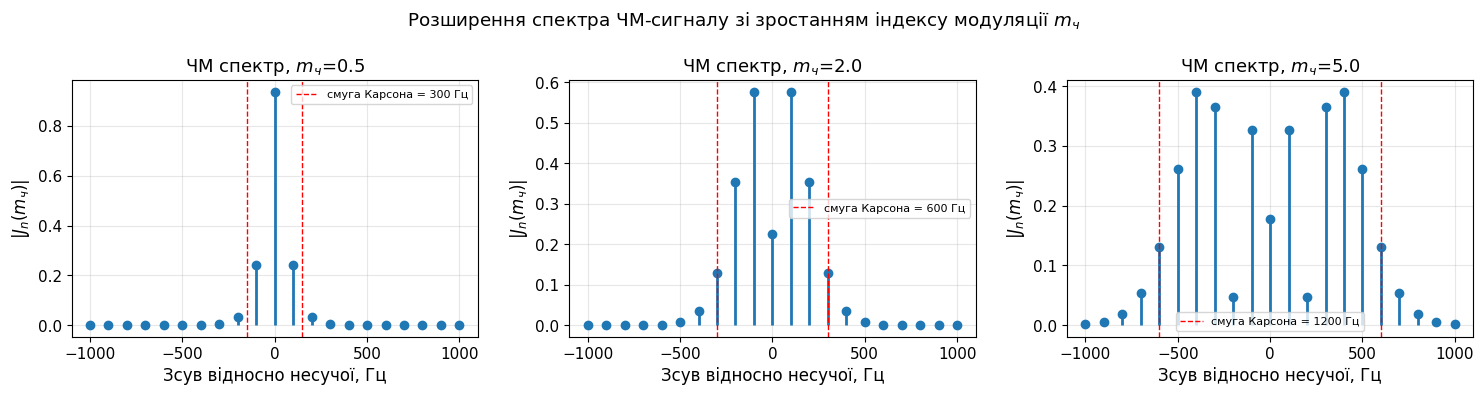

In [6]:
# Спектр частотно-модульованого сигналу через функції Бесселя (формула Карсона)
from scipy.special import jv

F_fm = 100.0
n_max = 10
ns_fm = np.arange(-n_max, n_max+1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mf in zip(axes, [0.5, 2.0, 5.0]):
    amps_fm = np.abs(jv(ns_fm, mf))
    ax.stem(ns_fm*F_fm, amps_fm, basefmt=' ')
    carson_bw = 2*F_fm*(mf+1)
    ax.axvline(carson_bw/2, color='red', ls='--', lw=1)
    ax.axvline(-carson_bw/2, color='red', ls='--', lw=1, label=f'смуга Карсона = {carson_bw:.0f} Гц')
    ax.set_xlabel('Зсув відносно несучої, Гц'); ax.set_ylabel('$|J_n(m_ч)|$')
    ax.set_title(f'ЧМ спектр, $m_ч$={mf}')
    ax.legend(fontsize=8)
plt.suptitle('Розширення спектра ЧМ-сигналу зі зростанням індексу модуляції $m_ч$')
plt.tight_layout(); plt.show()


### Сигнали з обмеженим спектром <a class="anchor" id="band-limited-signals"></a>

Сигнал $s(t)$ називають **сигналом з обмеженим спектром**, якщо його спектральна густина дорівнює нулю поза деякою смугою: $F(j\omega)=0$ при $|\omega|>\omega_{max}=2\pi F_{max}$.

Строго кажучи, сигнал не може бути **одночасно** обмеженим і за часом, і за спектром (принцип невизначеності для сигналів: $\Delta t\cdot\Delta f \ge \text{const}$) — нескінченно довгий у часі сигнал теоретично потрібен, щоб мати строго нульовий спектр поза смугою. На практиці, однак, енергія реальних сигналів природно зосереджена у скінченній смузі частот, а позасмугова частина настільки мала, що нею нехтують без відчутної похибки.

Припущення про обмежений спектр — фундаментальна основа для **теореми Котельникова** (нижче): без нього неможливо точно (без втрати інформації) дискретизувати сигнал скінченною кількістю відліків.


### Теорема Котельникова. Побудова ортонормованого базису та ряд Котельникова <a class="anchor" id="kotelnikov-theorem"></a>

**Формулювання (теорема Котельникова, або Найквіста–Шеннона):** якщо сигнал $s(t)$ має спектр, обмежений частотою $F_{max}$, то він **повністю й однозначно** визначається своїми відліками (миттєвими значеннями), взятими через інтервал

$$\Delta t = \frac{1}{2F_{max}} \qquad\Longleftrightarrow\qquad f_д \ge 2F_{max} \;\text{(умова Найквіста)}$$

**Ряд Котельникова** (формула точного відновлення сигналу з відліків):

$$s(t) = \sum_{k=-\infty}^{\infty} s(k\Delta t)\cdot\operatorname{sinc}\!\left(\frac{t-k\Delta t}{\Delta t}\right), \qquad \operatorname{sinc}(x)=\frac{\sin(\pi x)}{\pi x}$$

Базисні функції $\varphi_k(t)=\operatorname{sinc}\!\left(\dfrac{t}{\Delta t}-k\right)$ утворюють **ортонормований базис** у просторі сигналів з обмеженим спектром $F_{max}$: інтеграл добутку двох зсунутих sinc-функцій дорівнює $\displaystyle\int\varphi_k(t)\varphi_l(t)\,dt=\Delta t\cdot\delta_{kl}$ — це прямий приклад скалярного добутку й ортогональності з розділу «Функціональний аналіз» вище. Коефіцієнти розкладу за цим базисом (узагальнений ряд Фур'є, розділ вище) якраз і є самі відліки сигналу $s(k\Delta t)$.

**Якщо умова Найквіста не виконується** ($f_д<2F_{max}$), спектри сусідніх копій сигналу (що виникають при дискретизації) перекриваються — виникає **накладання спектрів (аліасинг)**, і точне відновлення оригінального сигналу за відліками стає неможливим. Саме тому перед АЦП завжди встановлюють **протиаліасинговий (anti-aliasing) фільтр**, що обмежує смугу вхідного сигналу до $F_{max}<f_д/2$.


Продемонструємо теорему Котельникова: дискретизуємо сигнал і відновимо його рядом Котельникова (сумою функцій sinc).

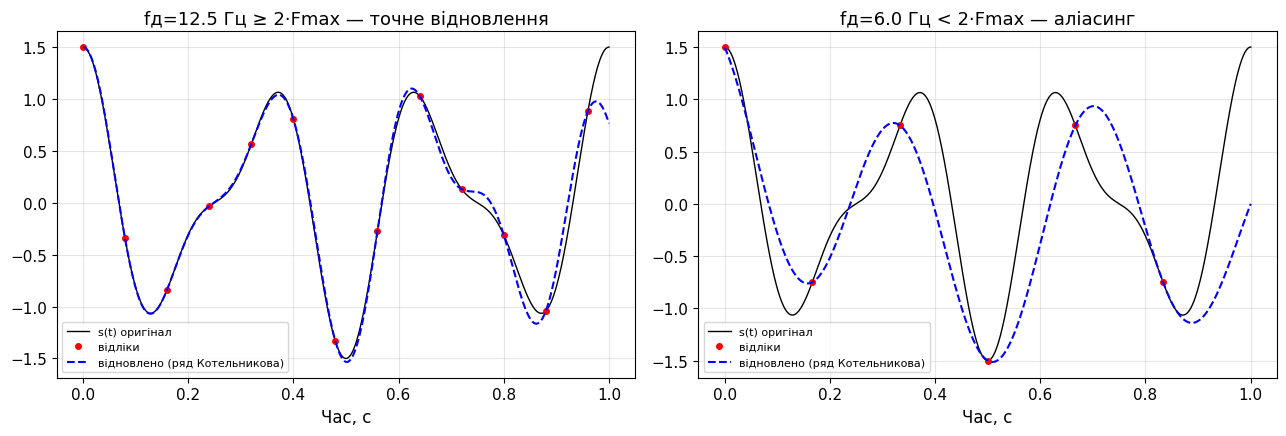

Fmax = 5.0 Гц, умова Найквіста: fд ≥ 10.0 Гц


In [7]:
# Демонстрація теореми Котельникова: дискретизація і точне відновлення сигналу з обмеженим спектром
Fmax_k = 5.0             # максимальна частота в спектрі сигналу, Гц
fd_ok = 2.5*Fmax_k       # частота дискретизації ВИЩЕ Найквіста (умова виконана)
fd_bad = 1.2*Fmax_k      # частота дискретизації НИЖЧЕ Найквіста (аліасинг)

def s_signal(t):
    return np.cos(2*np.pi*3*t) + 0.5*np.cos(2*np.pi*Fmax_k*t)

t_cont = np.linspace(0, 1, 4000)
s_cont = s_signal(t_cont)

def sample_and_reconstruct(fd):
    dt = 1/fd
    t_samples = np.arange(0, 1, dt)
    s_samples = s_signal(t_samples)
    # ряд Котельникова: сума зсунутих sinc
    recon = np.array([np.sum(s_samples*np.sinc((tt-t_samples)/dt)) for tt in t_cont])
    return t_samples, s_samples, recon

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, fd, title in [(axes[0], fd_ok, f'fд={fd_ok:.1f} Гц ≥ 2·Fmax — точне відновлення'),
                       (axes[1], fd_bad, f'fд={fd_bad:.1f} Гц < 2·Fmax — аліасинг')]:
    t_s, s_s, recon = sample_and_reconstruct(fd)
    ax.plot(t_cont, s_cont, 'k-', lw=1, label='s(t) оригінал')
    ax.plot(t_s, s_s, 'ro', ms=4, label='відліки')
    ax.plot(t_cont, recon, 'b--', lw=1.5, label='відновлено (ряд Котельникова)')
    ax.set_xlabel('Час, с'); ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Fmax = {Fmax_k} Гц, умова Найквіста: fд ≥ {2*Fmax_k} Гц')


---
### 🔬 Інтерактивно: частота дискретизації та накладання спектрів (aliasing) <a class="anchor" id="aliasing-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Сигнал містить гармоніки 1 Гц і 3 Гц, тобто $F_{max} = 3$ Гц. Змінюйте частоту дискретизації $f_д$: при $f_д > 2F_{max} = 6$ Гц ряд Котельникова точно відновлює сигнал; при $f_д < 6$ Гц виникає **накладання спектрів** — відновлюється зовсім інший, «несправжній» сигнал.

</div>

In [8]:
# Інтерактивно: дискретизація та відновлення рядом Котельникова, накладання спектрів
def aliasing_demo(fs=8.0):
    s = lambda t: np.sin(2*np.pi*1*t) + 0.6*np.sin(2*np.pi*3*t + 0.5)   # F_max = 3 Гц
    t = np.linspace(0, 3, 3000)
    dt = 1/fs
    n = np.arange(-60, int(3*fs) + 60)                   # відліки із запасом для суми ряду
    tn = n*dt
    rec = np.sum(s(tn)[:, None]*np.sinc((t[None, :] - tn[:, None])/dt), axis=0)
    err = np.sqrt(np.mean((rec - s(t))**2))
    ok = fs > 6
    plt.figure(figsize=(12, 4))
    plt.plot(t, s(t), 'k', lw=1.5, label='вихідний сигнал')
    plt.plot(t, rec, 'g' if ok else 'r', lw=2, alpha=0.8, label='відновлений рядом Котельникова')
    m = (tn >= 0) & (tn <= 3)
    plt.stem(tn[m], s(tn[m]), linefmt='C0-', markerfmt='C0o', basefmt=' ', label='відліки')
    plt.title(f'$f_д$ = {fs:.1f} Гц ({"> " if ok else "≤ "}2$F_{{max}}$ = 6 Гц), СКП відновлення = {err:.3f}',
              color='g' if ok else 'r')
    plt.xlabel('t, c'); plt.legend(loc='upper right'); plt.xlim(0, 3)
    plt.show()

interact(aliasing_demo, fs=widgets.FloatSlider(value=8, min=2, max=20, step=0.5, description='f_д, Гц'));

interactive(children=(FloatSlider(value=8.0, description='f_д, Гц', max=20.0, min=2.0, step=0.5), Output()), _…

---
### ⚡ Практичне застосування: Кореляційний аналіз і модуляція сигналів

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Застосування | Що саме використовується |
|--------------|-----------------------------|
| **Радіолокація, гідролокація, GPS** | Взаємокореляція прийнятого сигналу з опорним — вимірювання затримки (відстані) |
| **Синхронізація в цифровому зв'язку (Wi-Fi, LTE, 5G)** | Автокореляція преамбули для виявлення початку кадру й символьної синхронізації |
| **Радіомовлення АМ (ДХ/СХ/КХ)** | Класична АМ — простий детектор обвідної на прийомі |
| **Стереомовлення УКХ, супутниковий зв'язок** | Балансна й однополосна модуляція — економія потужності і смуги |
| **Радіомовлення ЧМ (УКХ), стільниковий зв'язок** | Частотна модуляція — висока завадостійкість |
| **АЦП, цифрова обробка сигналів** | Теорема Котельникова визначає мінімально допустиму частоту дискретизації; протиаліасинговий фільтр — обов'язковий елемент будь-якого АЦП-тракту |

</div>

---
### ✅ Питання для самоперевірки: Кореляційний аналіз та модуляція сигналів

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чим енергетичний спектр одного сигналу відрізняється від взаємної спектральної густини двох сигналів?</summary>

> **Відповідь:** Енергетичний спектр $W(\omega)=|F(j\omega)|^2$ одного сигналу — дійсна, невід'ємна, парна функція. Взаємна спектральна густина $W_{xy}(\omega)=X(j\omega)Y^*(j\omega)$ двох різних сигналів — комплексна і, взагалі, не парна функція; вона характеризує узгодженість (кореляцію) сигналів на кожній частоті, а не енергію одного сигналу.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому автокореляційна функція завжди досягає максимуму саме при τ=0?</summary>

> **Відповідь:** $R_x(0)=\int|x(t)|^2dt=E$ — енергія сигналу. За нерівністю Коші–Буняковського $|R_x(\tau)|\le R_x(0)$ для будь-якого зсуву τ: жодна зсунута копія сигналу не може корелювати з оригіналом сильніше, ніж сигнал сам із собою без зсуву.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як взаємокореляційна функція дозволяє визначити затримку сигналу (наприклад, у радарі)?</summary>

> **Відповідь:** Обчислюють $R_{xy}(\tau)$ між випроміненим (опорним) і прийнятим (відбитим) сигналами для різних τ; положення максимуму $\tau_{max}$ вказує затримку поширення сигналу, за якою (знаючи швидкість поширення) обчислюють відстань до цілі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> У чому головний недолік класичної амплітудної модуляції з погляду енергетики?</summary>

> **Відповідь:** При максимальній глибині модуляції m=1 обидві бічні смуги (які й переносять інформацію) несуть разом лише 1/3 повної потужності сигналу — решта 2/3 витрачається на несучу, яка сама по собі інформації не містить.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Чим балансна модуляція (ДБП) відрізняється від класичної АМ і яка за це ціна?</summary>

> **Відповідь:** У ДБП несуча пригнічена, вся потужність зосереджена в двох бічних смугах — це ефективніше використання потужності передавача. Ціна — потрібне когерентне (синхронне) детектування на прийомі, оскільки простий детектор обвідної без несучої не працює.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 6.</b> Чому спектр ЧМ-сигналу (навіть при тональній модуляції) містить нескінченну кількість бічних складових, на відміну від АМ?</summary>

> **Відповідь:** Амплітуда ЧМ-коливання $U_m\cos(\omega_0t+m_ч\sin\Omega t)$ — нелінійна функція часу (аргумент косинуса містить $\sin\Omega t$ всередині), тому розклад у ряд Фур'є за гармоніками $\Omega$ дає нескінченну суму членів з коефіцієнтами — функціями Бесселя $J_n(m_ч)$, а не лише дві бічні складові, як у лінійній (за амплітудою) АМ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 7.</b> Сигнал має максимальну частоту спектра Fmax=4 кГц. Яка мінімальна частота дискретизації і мінімальний інтервал між відліками?</summary>

> **Відповідь:** $f_д\ge2F_{max}=8$ кГц (умова Найквіста), $\Delta t=1/(2F_{max})=125$ мкс.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 8.</b> Що станеться, якщо дискретизувати сигнал з частотою, нижчою за частоту Найквіста?</summary>

> **Відповідь:** Виникне накладання (аліасинг) спектрів сусідніх копій дискретизованого сигналу — високочастотні складові оригіналу «підмінять» низькочастотні в спектрі відновленого сигналу, і точне відновлення оригінального сигналу за відліками стане неможливим.

</details>

---
### 📝 Задачі для самостійного розв'язання: Кореляційний аналіз та модуляція


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Несуча 1 МГц з амплітудою 10 В модульована тоном $F = 5$ кГц з $m = 0{,}5$. Знайдіть частоти й амплітуди бічних складових, ширину спектра і частку потужності в бічних смугах.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Бічні: 995 кГц і 1005 кГц, амплітуди $mU_0/2 = 2{,}5$ В; ширина спектра $2F = 10$ кГц; частка потужності $\dfrac{m^2}{2 + m^2} \approx 11{,}1\,\%$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** ЧМ-радіомовлення: девіація $\Delta f = 75$ кГц, найвища модулююча частота $F = 15$ кГц. Знайдіть індекс модуляції та ширину спектра за Карсоном.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\beta = \Delta f/F = 5$; $B \approx 2(\Delta f + F) = 180$ кГц.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Спектр мовного сигналу обмежено частотою 4 кГц. Яка мінімальна частота дискретизації за Котельниковим, крок дискретизації та кількість відліків за 1 с?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f_д \ge 2F_{max} = 8$ кГц; $\Delta t = 125$ мкс; 8000 відліків/с (стандарт телефонії).

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Чому дорівнює значення автокореляційної функції прямокутного імпульсу ($A$, $\tau$) при нульовому зсуві, і яка ширина АКФ?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $B(0) = A^2\tau$ — енергія сигналу; АКФ має форму трикутника шириною $2\tau$ (відмінна від нуля при $|\theta| < \tau$).

</details>

---

## 📌 Підсумок курсу: Основи радіоелектроніки. Частина 2 <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

### Зведена таблиця методів аналізу перехідних процесів

| Метод | Область застосування | Переваги | Обмеження |
|-------|---------------------|---------|-----------|
| **Класичний** | Прості RL, RC ланцюги | Наочний, фізична інтерпретація | Складний для вищих порядків |
| **Операторний (Лапласа)** | Будь-які лінійні кола | Зведення до алгебри, враховує початкові умови | Потребує таблиць |
| **Частотний (Фур'є)** | Стаціонарні сигнали | Спектральний аналіз, фільтрація | Тільки для стаціонарних сигналів |

### Зв'язок між методами

$$\text{Часова область} \xleftrightarrow{\mathcal{L}} \text{Операторна (Лапласа)} \xleftrightarrow{p=j\omega} \text{Частотна (Фур'є)}$$

### ⚡ Практичне застосування в радіотехніці

- **RL, RC ланцюги** — фільтри, інтегруючі та диференціюючі схеми
- **RLC ланцюги** — резонансні підсилювачі, смугові фільтри, осцилятори
- **Довга лінія** — коаксіальні кабелі, мікросмужкові лінії, антенні фідери
- **Ряди Фур'є** — спектральний аналіз, модуляція, синтез сигналів

</div>


---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 15. Ряди та перетворення Фур'є](Тема_15_Ряди_та_перетворення_Фурє.ipynb)</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
